# Aim: To perform text mining using textblob in python (TF-IDF generation, sentiment analysis, word-cloud, POS tagging)

# TextBlob creates a blob object from input Text. 
# Blob object is made of Sentence Objects, each Sentence Object has WordList which is collection of Word objects present in the Sentence. 
# TextBlob provides various operations as Blob level, sentence level and word level. 
# For example, POS tagging is done at blob level. Sentiment analysis is done at sentence level. Inflection and Lemmatization done at word level.

In [4]:
# Install and Import TextBlob
!pip install textblob

   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------------------------------- 624.3/624.3 kB 7.7 MB/s eta 0:00:00


In [9]:
from textblob import TextBlob
from textblob import download_corpora 

In [10]:
# Create a TextBlob Object from Text
blob = TextBlob('''DDU is thE bEsTt univercity''')
blob1 = TextBlob('''speling mustake''')


In [11]:
blob.correct() #will correct the spelling mistakes if any.

TextBlob("DDU is the best university")

In [12]:
blob1.correct()

TextBlob("spelling mistake")

# TF-IDF-in-Python-using-TextBlob
# Term Frequency (TF) : local frequency of a word in the document i.e. the word is weighed by how many times it occurs in the document
# Document Frequency (DF) : Global frequency of a word in the document collection . It is the number of documents that contain the word.
# Inverse Document Frequency (IDF) : we're interested in words that are rare across the document collections. They tend to be domain specific and are usually more relevant for retrieving this document . So we should give them more weight than to high-frequency words .
# 


In [11]:
import nltk
from nltk.tokenize import sent_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')
from sklearn.feature_extraction.text import TfidfVectorizer

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Define Document as a name sentance

In [13]:
sentence = """Manchester City makes history by winning Club World Cup

Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.

Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola’s side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.

The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.

“We’ve shown over the past 12 months we are the best team in the world. Our results prove that and the consistency we have managed has been amazing,” club captain Kyle Walker said after the game, per Sky Sports.

“To win these five trophies – for me, the five biggest prizes available to us – is incredible. I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players. I couldn’t ask for better teammates.”

It took just 40 seconds for Manchester City to take the lead.

Brazilian left-back Marcelo miscued a pass in the opening exchanges which let Nathan Aké free to shoot from distance. The defender’s effort cannoned back off the post but forward Julián Álvarez was in the right place to turn the rebound into the net with his chest.

City continued to look dangerous and doubled its lead before the break after Phil Foden’s attempted cross was deflected into his own net by Fluminense defender Nino.

Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range.

The rout was completed in the 88th minute when Álvarez capped off a brilliant performance with a clinical finish into the far corner.

City’s defence was largely untested for during the game, underlining the team’s dominance during this unforgettable year.

“As a manager it is what I am most proud of; that we are always there. No matter how much we win, no matter what trophies we lift, we are there again to fight for the next one,” City boss Guardiola said after the match, according to Sky Sports.

“To win the Treble was truly special, but to win two more trophies and now hold these five major titles shows the unique mentality of this team, of the Club and its fans.

“It is something no other English team has ever achieved, and we will always remember this incredible time we spent together.”

The game ended in some unsavoury scenes as a scuffle broke out between players on the pitch after the final whistle, but the game will be remembered as yet another successful night for City.

The champion heads back to England where it faces a tough title defence in the Premier League.

It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.
"""

# Text Preprocessing of this paragraph

In [16]:
# Sentence tokenization
sent_token = sent_tokenize(sentence)
print(sent_token)

['Manchester City makes history by winning Club World Cup\n\nManchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.', 'Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola’s side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.', 'The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.', '“We’ve shown over the past 12 months we are the best team in the world.', 'Our results prove that and the consistency we have managed has been amazing,” club captain Kyle Walker said after the game, per Sky Sports.', '“To win these five trophies – for me, the five biggest prizes available to us – is incredible.', 'I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players.', 'I could

In [19]:
# Training TF-IDF Vectorizer on sentences
vectorizer = TfidfVectorizer(stop_words='english')
features = vectorizer.fit_transform(sent_token)

# Calculate Sentence Score 

In [20]:
# Variable initialization
sent_index = 0
sent_scores = []

# Calculate sentence TF-IDF score
for i in features :
  print(f"- Sentences {sent_index + 1}")
  sent_score = i.sum()
  sent_length = len(i.data)
  print("Sum of sentence TF-IDF score: ", sent_score)
  print("Length of sentence (number of words): ", sent_length)
  avg_score = sent_score/sent_length
  print("Average TF-IDF score: ", avg_score)
  print("-------------------------")
  sent_index +=1
  sent_scores.append(avg_score)

- Sentences 1
Sum of sentence TF-IDF score:  3.8372306490586197
Length of sentence (number of words):  16
Average TF-IDF score:  0.23982691556616373
-------------------------
- Sentences 2
Sum of sentence TF-IDF score:  4.207677634042787
Length of sentence (number of words):  19
Average TF-IDF score:  0.2214567175811993
-------------------------
- Sentences 3
Sum of sentence TF-IDF score:  3.712821825324859
Length of sentence (number of words):  14
Average TF-IDF score:  0.26520155895177566
-------------------------
- Sentences 4
Sum of sentence TF-IDF score:  2.814845194495448
Length of sentence (number of words):  8
Average TF-IDF score:  0.351855649311931
-------------------------
- Sentences 5
Sum of sentence TF-IDF score:  3.588741191885733
Length of sentence (number of words):  13
Average TF-IDF score:  0.276057014760441
-------------------------
- Sentences 6
Sum of sentence TF-IDF score:  2.4238363903356595
Length of sentence (number of words):  6
Average TF-IDF score:  0.40397

In [21]:
len(sent_scores)

20

In [22]:
len(sent_token)

20

In [23]:
sum(sent_scores)

6.302828037602822

# Define Threshold 

In [24]:
threshold = sum(sent_scores)/len(sent_scores) # Average of Sentence Scores
threshold

0.3151414018801411

# Get Sentences and final summarization result

In [26]:
# Final summary initialization
final_summ = ""

# Get summary sentences
for index, data in enumerate(sent_scores) :
  if (data >= (threshold)) :
    final_summ = final_summ + " " + sent_token[index]
    print("- ", sent_token[index])

-  “We’ve shown over the past 12 months we are the best team in the world.
-  “To win these five trophies – for me, the five biggest prizes available to us – is incredible.
-  I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players.
-  Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range.
-  “As a manager it is what I am most proud of; that we are always there.
-  The champion heads back to England where it faces a tough title defence in the Premier League.
-  It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.


In [27]:
final_summ

' “We’ve shown over the past 12 months we are the best team in the world. “To win these five trophies – for me, the five biggest prizes available to us – is incredible. I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players. Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range. “As a manager it is what I am most proud of; that we are always there. The champion heads back to England where it faces a tough title defence in the Premier League. It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.'

# SENTIMENT ANALYSIS OF TEXT MESSAGES
# Sentiment analysis of text messages is the process of determining the sentiment or emotional tone expressed. It involves analyzing the text to identify and categorize the sentiment as positive, negative, or neutral. The goal is to understand the subjective opinions, attitudes, or emotions conveyed by the text.

# TextBlob is used in sentiment analysis of text messages, offering different functionalities and approaches. Neattext is used for data cleaning an pre-processing of data
# TextBlob - TextBlob is a Python library that provides a simple and intuitive API for natural language processing tasks, including sentiment analysis. It offers built-in sentiment analysis capabilities based on pre-trained models.TextBlob's sentiment analysis feature provides a polarity score and subjectivity score for a given text. The polarity score indicates the sentiment as positive (score > 0), negative (score < 0), or neutral (score = 0), while the subjectivity score represents the degree of subjective or objective nature of the text
# NeatText - NeatText is a Python library that offers text preprocessing functions for cleaning and normalizing text data. It provides various text cleaning operations to remove noise, normalize text, and handle common text-related issues.NeatText offers functions to remove special characters, URLs, email addresses, numbers, and other unwanted elements from text. It helps to eliminate noise and focus on the meaningful content for sentiment analysis.

# About the dataset
# The dataset initialy contains 2 features

# Emotion
# Text
# Emotion has 8 particulars namely,

# Joy
# Anger
# Sad
# Surprise
# Disgust
# Shame
# Neutral
# Fear
# Text has the messages on which the Analysis is to be performed

In [2]:
!pip install neattext

In [3]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import neattext.functions as nfx
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# Importing the data
df=pd.read_csv("dataset.csv")
df.head()

,Emotion,Text
0,neutral,Why ?
1,joy,Sage Act upgrade on my to do list for tommorow.
2,sadness,ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...
3,joy,Such an eye ! The true hazel eye-and so brill...
4,joy,@Iluvmiasantos ugh babe.. hugggzzz for u .! b...


In [5]:
df.tail()

,Emotion,Text
34787,surprise,@MichelGW have you gift! Hope you like it! It'...
34788,joy,The world didnt give it to me..so the world MO...
34789,anger,A man robbed me today .
34790,fear,"Youu call it JEALOUSY, I call it of #Losing YO..."
34791,sadness,"I think about you baby, and I dream about you ..."


In [6]:
# Statistical Exploration of the data
df.shape

(34792, 2)

In [7]:
df.describe()

,Emotion,Text
count,34792,34792
unique,8,31105
top,joy,Yes .
freq,11045,76


In [8]:
df.isnull().sum()

Emotion    0
Text       0
dtype: int64

In [9]:
df['Emotion'].value_counts()

Emotion
joy         11045
sadness      6722
fear         5410
anger        4297
surprise     4062
neutral      2254
disgust       856
shame         146
Name: count, dtype: int64

<Axes: xlabel='Emotion'>

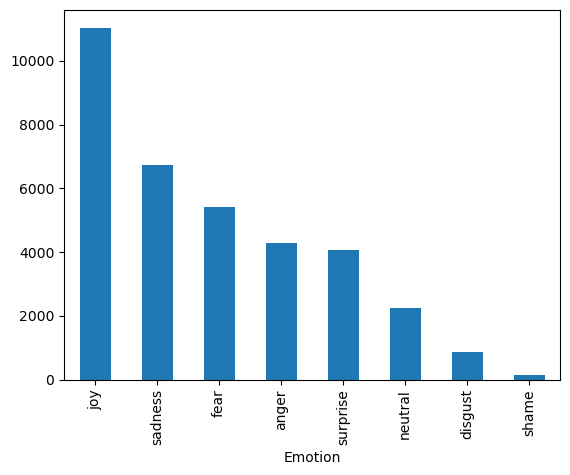

In [10]:
# Visualizing the emotion feature
df['Emotion'].value_counts().plot(kind='bar')

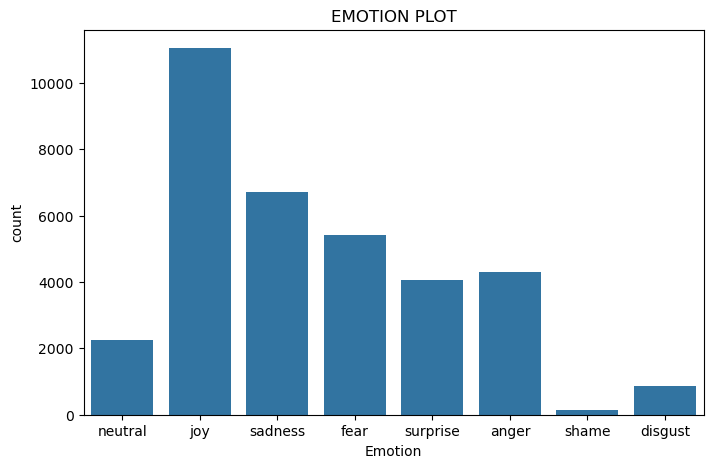

In [11]:
plt.figure(figsize=(8,5))
plt.title("EMOTION PLOT")
sns.countplot(x='Emotion',data=df)
plt.show()

In [12]:
# Performing Sentiment Analysis using TextBlob
from textblob import TextBlob

In [13]:
def get_sentiment(text):
    blob=TextBlob(text)
    sentiment= blob.sentiment.polarity
    if sentiment >0:
        result='Positive'
    elif sentiment <0:
        result= 'Negative'
    else:
        result= 'Neutral'
    return result

In [14]:
get_sentiment('I was late to my class')

'Negative'

# Analysed result using TextBlob is appied to every "TEXT" feature of the data to predict the emotional tone. The obtained result is stored as a seperate feature in the dataset and compared with the actual emotion

In [15]:
df['Sentiment']=df['Text'].apply(get_sentiment)
df.head()

,Emotion,Text,Sentiment
0,neutral,Why ?,Neutral
1,joy,Sage Act upgrade on my to do list for tommorow.,Neutral
2,sadness,ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...,Negative
3,joy,Such an eye ! The true hazel eye-and so brill...,Positive
4,joy,@Iluvmiasantos ugh babe.. hugggzzz for u .! b...,Neutral


In [16]:
#comparison of actual and predicted
df.groupby(['Emotion','Sentiment']).size()

Emotion   Sentiment
anger     Negative     1787
          Neutral      1386
          Positive     1124
disgust   Negative      324
          Neutral       251
          Positive      281
fear      Negative     1535
          Neutral      1844
          Positive     2031
joy       Negative     1682
          Neutral      3649
          Positive     5714
neutral   Negative      178
          Neutral      1523
          Positive      553
sadness   Negative     2629
          Neutral      2128
          Positive     1965
shame     Negative       46
          Neutral        50
          Positive       50
surprise  Negative      623
          Neutral      1546
          Positive     1893
dtype: int64

Text(0.5, 1.0, 'PREDICTED EMOTION')

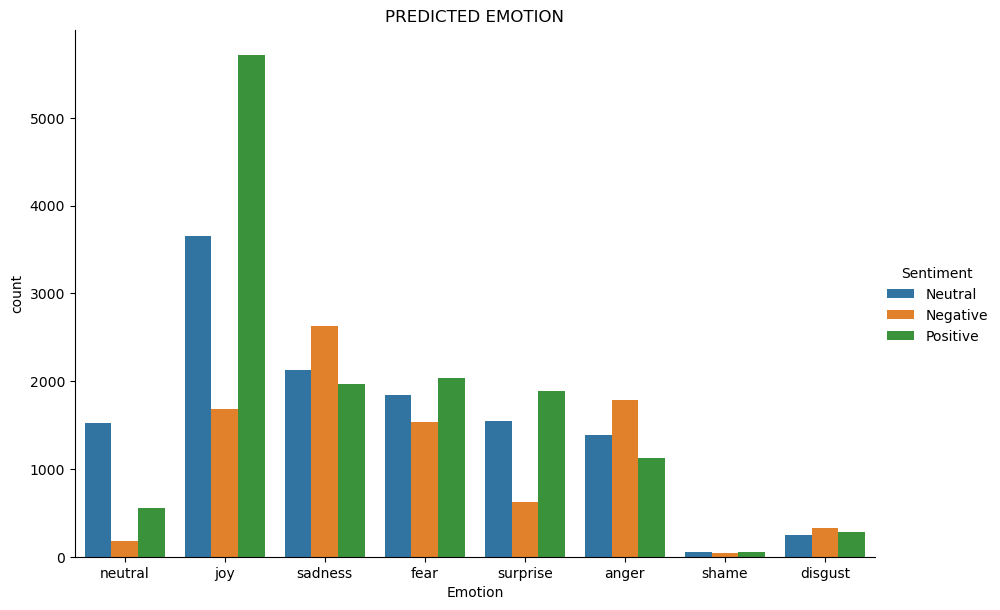

In [20]:
# Plotting predicted emotion using TextBlob
sns.catplot(x='Emotion',hue='Sentiment',data=df,kind='count',height=6,aspect=1.5)
plt.title("PREDICTED EMOTION")

# Text Cleaning
# This function returns a list of all the attributes and methods available in the nfx module of the neattext library performing the following functions

# removes stopwords
# removes punctuations
# removes usernames
# removes urls
# removes emails
# removes hashtags
# removes numbers
# removes special characters
# removes multiple spaces

In [21]:
dir(nfx)

['BTC_ADDRESS_REGEX',
 'CURRENCY_REGEX',
 'CURRENCY_SYMB_REGEX',
 'Counter',
 'DATE_REGEX',
 'EMAIL_REGEX',
 'EMOJI_REGEX',
 'HASTAG_REGEX',
 'MASTERCard_REGEX',
 'MD5_SHA_REGEX',
 'MOST_COMMON_PUNCT_REGEX',
 'NUMBERS_REGEX',
 'PHONE_REGEX',
 'PoBOX_REGEX',
 'SPECIAL_CHARACTERS_REGEX',
 'STOPWORDS',
 'STOPWORDS_de',
 'STOPWORDS_en',
 'STOPWORDS_es',
 'STOPWORDS_fr',
 'STOPWORDS_ru',
 'STOPWORDS_yo',
 'STREET_ADDRESS_REGEX',
 'TextFrame',
 'URL_PATTERN',
 'USER_HANDLES_REGEX',
 'VISACard_REGEX',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__generate_text',
 '__loader__',
 '__name__',
 '__numbers_dict',
 '__package__',
 '__spec__',
 '_lex_richness_herdan',
 '_lex_richness_maas_ttr',
 'clean_text',
 'defaultdict',
 'digit2words',
 'extract_btc_address',
 'extract_currencies',
 'extract_currency_symbols',
 'extract_dates',
 'extract_emails',
 'extract_emojis',
 'extract_hashtags',
 'extract_html_tags',
 'extract_mastercard_addr',
 'extract_md5sha',
 'extract_numbers',
 'extr

In [22]:
df['Text']

0                                                   Why ? 
1          Sage Act upgrade on my to do list for tommorow.
2        ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...
3         Such an eye ! The true hazel eye-and so brill...
4        @Iluvmiasantos ugh babe.. hugggzzz for u .!  b...
                               ...                        
34787    @MichelGW have you gift! Hope you like it! It'...
34788    The world didnt give it to me..so the world MO...
34789                             A man robbed me today . 
34790    Youu call it JEALOUSY, I call it of #Losing YO...
34791    I think about you baby, and I dream about you ...
Name: Text, Length: 34792, dtype: object

In [23]:
df['Clean_text']=df['Text'].apply(nfx.remove_stopwords)

In [24]:
df['Clean_text']=df['Clean_text'].apply(nfx.remove_punctuations)

In [25]:
df['Clean_text']=df['Clean_text'].apply(nfx.remove_userhandles)

In [26]:
df[['Text','Clean_text']]

,Text,Clean_text
0,Why ?,
1,Sage Act upgrade on my to do list for tommorow.,Sage Act upgrade list tommorow
2,ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...,WAY HOMEGIRL BABY FUNERAL MAN HATE FUNERALS SH...
3,Such an eye ! The true hazel eye-and so brill...,eye true hazel eyeand brilliant Regular feat...
4,@Iluvmiasantos ugh babe.. hugggzzz for u .! b...,ugh babe hugggzzz u babe naamazed nga ako e...
...,...,...
34787,@MichelGW have you gift! Hope you like it! It'...,gift Hope like it hand wear Itll warm Lol
34788,The world didnt give it to me..so the world MO...,world didnt meso world DEFINITELY cnt away
34789,A man robbed me today .,man robbed today
34790,"Youu call it JEALOUSY, I call it of #Losing YO...",Youu JEALOUSY #Losing YOU


# The Counter class is a container that provides a convenient way to count the occurrences of elements in a collection or iterable. It is a specialized dictionary subclass where elements in the collection are stored as keys, and their counts are stored as values

In [27]:
from collections import Counter

In [28]:
def extract_keywords(text,num=50):
    tokens= [tok for tok in text.split()]
    most_common_tokens=Counter(tokens).most_common(num)
    return dict(most_common_tokens)

In [29]:
emotion_list=df['Emotion'].unique().tolist()

In [30]:
# Lisitng the different emotions displayed by the text messages
emotion_list

['neutral', 'joy', 'sadness', 'fear', 'surprise', 'anger', 'shame', 'disgust']

In [33]:
# Displaying the clean text messages which shows Joy emotion
joy_list=df[df['Emotion']=='joy']['Clean_text'].tolist()
joy_list

['Sage Act upgrade list tommorow',
 'eye  true hazel eyeand brilliant  Regular features  open countenance  complexion  Oh  bloom health  pretty height size  firm upright figure  health  merely bloom  air  head  glance  hears child  picture health    gives idea complete picture grownup health  loveliness ',
 '  ugh babe hugggzzz u  babe naamazed nga ako e babe e despite negas mas pinaramdam fil ko ang',
 'life  Leopold truly happy : hopes prayers beloved son come fruition ',
 'feeling fail french #fuckfrench',
 'GoodLet  ',
 'fell love \\X\\ Overnight felt confidence selfesteem responsible worthwhile',
 'terribly ecstatic dangerous thing ',
 'selected study university',
 'Yeah  ’ ages  ',
 'passed BA exams class results',
 'heard selected fot year university Zambia form Chikola secondary school',
 'Welp time study days',
 'Heading campus rain grad photos',
 'feeling awesome ',
 '  brings  Ive bought Christmas presents trawl loads shops :)',
 'shit pants Pure 100% gravy',
 'life  Leopold

In [34]:
joy_docx=''.join(joy_list)
joy_docx

'Sage Act upgrade list tommoroweye  true hazel eyeand brilliant  Regular features  open countenance  complexion  Oh  bloom health  pretty height size  firm upright figure  health  merely bloom  air  head  glance  hears child  picture health    gives idea complete picture grownup health  loveliness   ugh babe hugggzzz u  babe naamazed nga ako e babe e despite negas mas pinaramdam fil ko anglife  Leopold truly happy : hopes prayers beloved son come fruition feeling fail french #fuckfrenchGoodLet  fell love \\X\\ Overnight felt confidence selfesteem responsible worthwhileterribly ecstatic dangerous thing selected study universityYeah  ’ ages  passed BA exams class resultsheard selected fot year university Zambia form Chikola secondary schoolWelp time study daysHeading campus rain grad photosfeeling awesome   brings  Ive bought Christmas presents trawl loads shops :)shit pants Pure 100% gravylife  Leopold truly happy : hopes prayers beloved son come fruition Class jamming paper quarter rea

In [35]:
# Keyword Extraction
keyword_joy=extract_keywords(joy_docx)
keyword_joy

{'amp': 652,
 'day': 582,
 'time': 468,
 'Im': 453,
 'like': 439,
 'work': 400,
 'Christmas': 370,
 'today': 318,
 'good': 312,
 'tomorrow': 304,
 'happy': 303,
 'love': 283,
 'going': 283,
 'night': 249,
 'got': 248,
 'home': 248,
 'school': 233,
 '2': 232,
 'morning': 225,
 'joy': 214,
 'life': 208,
 'hours': 201,
 'feel': 193,
 'year': 183,
 'people': 179,
 'long': 178,
 's': 176,
 'new': 172,
 'great': 168,
 'days': 166,
 'week': 163,
 'sleep': 158,
 'know': 158,
 'family': 157,
 'RT': 156,
 'hour': 152,
 'God': 143,
 ':)': 143,
 'cant': 137,
 'excited': 135,
 'tonight': 134,
 'friends': 128,
 'feeling': 126,
 'felt': 126,
 'friend': 126,
 'right': 124,
 '3': 123,
 'old': 121,
 'me': 121,
 'think': 119}

In [36]:
def plot_common(mydict,name):
    df_1=pd.DataFrame(mydict.items(),columns=['token','count'])
    plt.figure(figsize=(20,8))
    plt.title("Plot of words depicting {}".format(name))
    sns.barplot(x='token',y='count',data=df_1)
    plt.xticks(rotation=90)
    plt.show()

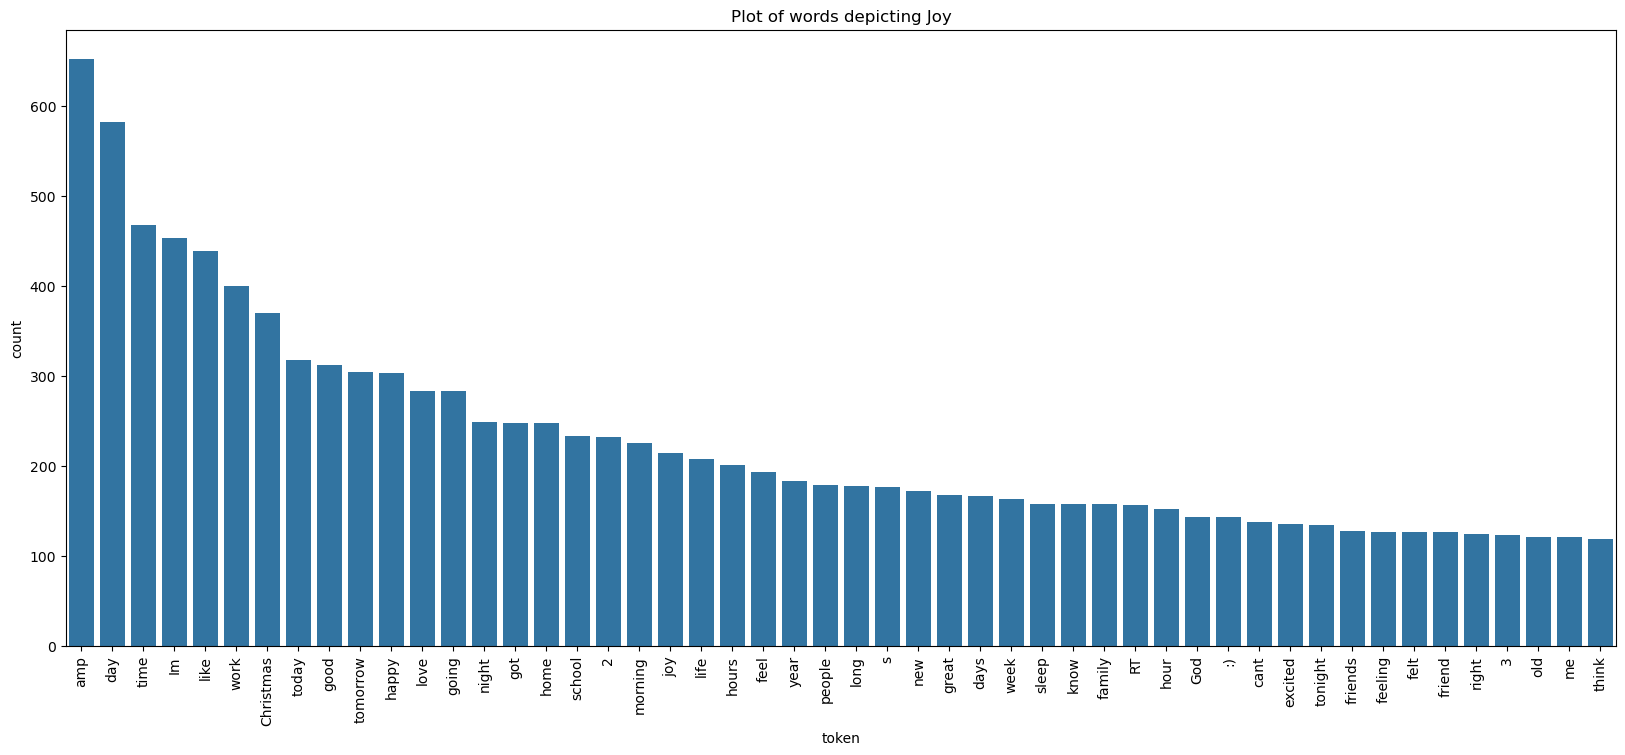

In [37]:
# Visualizing the keywords depicting Joy emotion
plot_common(keyword_joy,"Joy")

In [38]:
anger_list=df[df['Emotion']=='anger']['Clean_text'].tolist()

In [39]:
anger_docx=''.join(anger_list)

In [40]:
keyword_anger=extract_keywords(anger_docx)
keyword_anger

{'angry': 233,
 '’': 197,
 'anger': 186,
 'time': 169,
 'friend': 158,
 's': 156,
 'people': 155,
 'like': 151,
 'got': 141,
 'said': 116,
 'Im': 116,
 'told': 116,
 'felt': 104,
 'day': 103,
 'want': 102,
 'work': 99,
 'feel': 88,
 'going': 85,
 'cant': 81,
 'know': 80,
 'home': 79,
 'mad': 77,
 'way': 76,
 'exasperation': 76,
 'me': 75,
 'face': 75,
 'it': 75,
 'person': 75,
 'things': 75,
 'right': 74,
 'hate': 72,
 'good': 71,
 'car': 68,
 'resentful': 67,
 'away': 67,
 'think': 67,
 'went': 66,
 'wanted': 66,
 'furious': 65,
 'thought': 65,
 'annoyance': 64,
 'indignant': 64,
 'asked': 64,
 'amp': 61,
 'friends': 60,
 'mother': 60,
 'school': 58,
 'brother': 57,
 'man': 57,
 'night': 56}

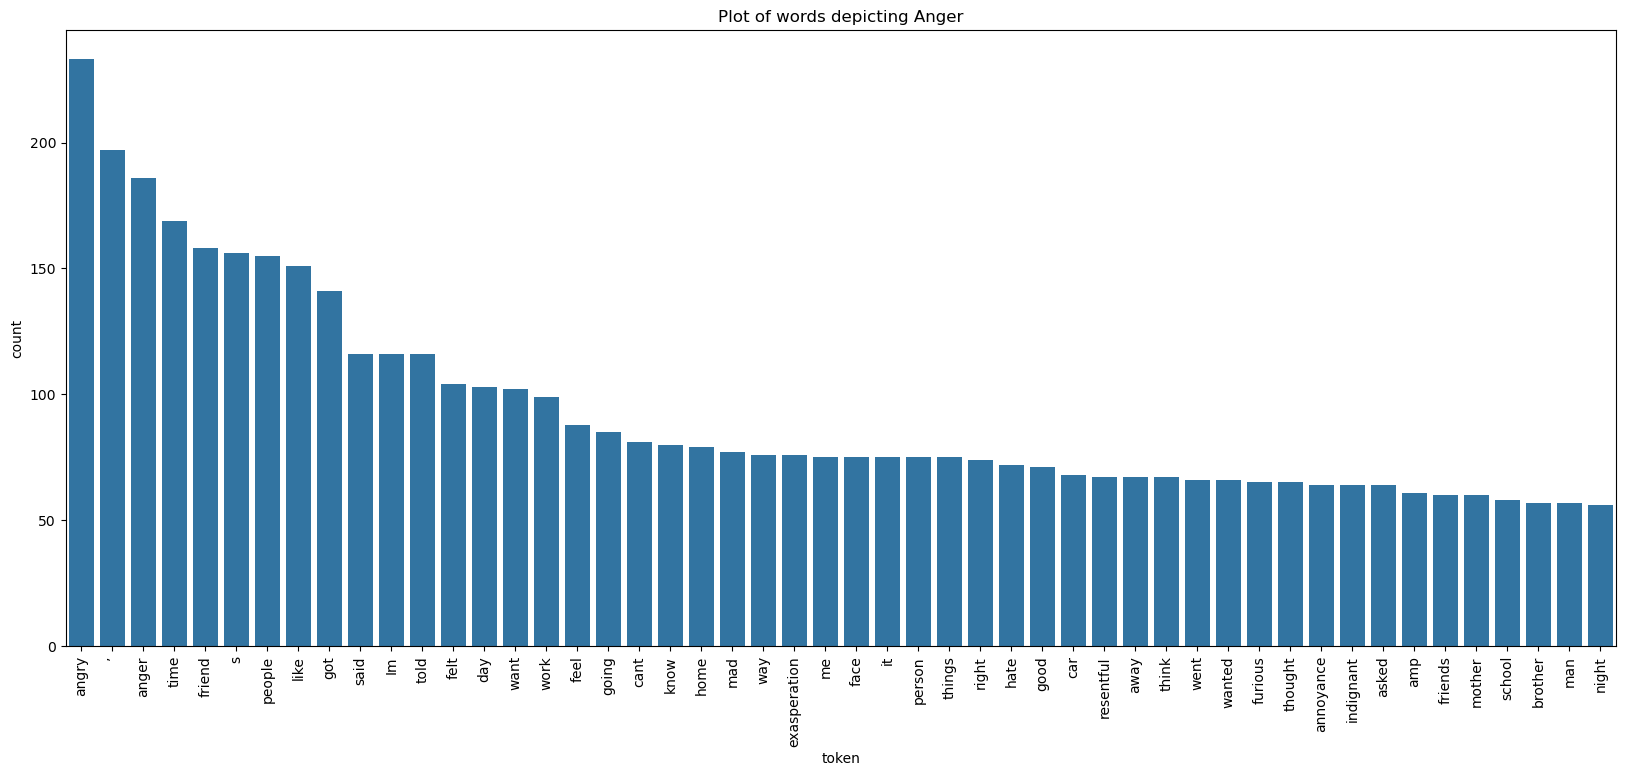

In [41]:
# Visualizng the keywords depicting Anger emotion
plot_common(keyword_anger,"Anger")

# Word Cloud
# A word cloud is a visualization technique used in sentiment analysis to represent the most frequent words or terms in a given text corpus. It provides a visual summary of the text data by displaying words in varying sizes, where the size corresponds to their frequency or importance.

# In sentiment analysis, a word cloud can be created to visualize the most commonly occurring words in positive, negative, or neutral sentiment categories. By analyzing the word cloud, one can quickly gain insights into the dominant sentiments expressed in a text corpus and identify the key themes or topics associated with each sentiment.

In [44]:
!pip install wordcloud

In [45]:
# Importing Word Cloud
from wordcloud import WordCloud

In [46]:
def plot_cloud(docx):
    myWC= WordCloud().generate(docx)
    plt.figure(figsize=(20,10))
    plt.imshow(myWC,interpolation='bilinear')
    plt.axis('off')
    plt.show()

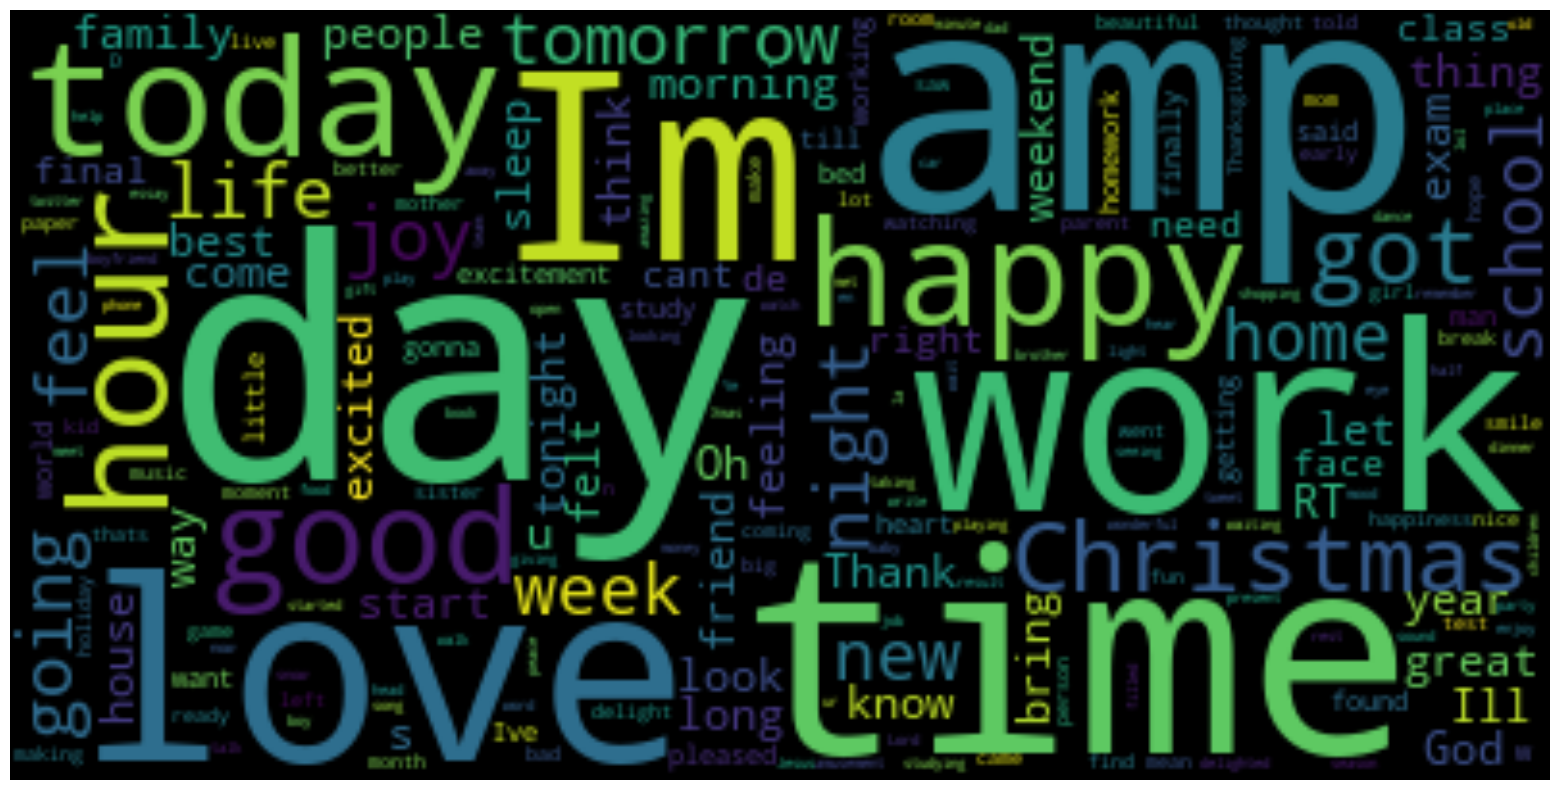

In [47]:
plot_cloud(joy_docx)

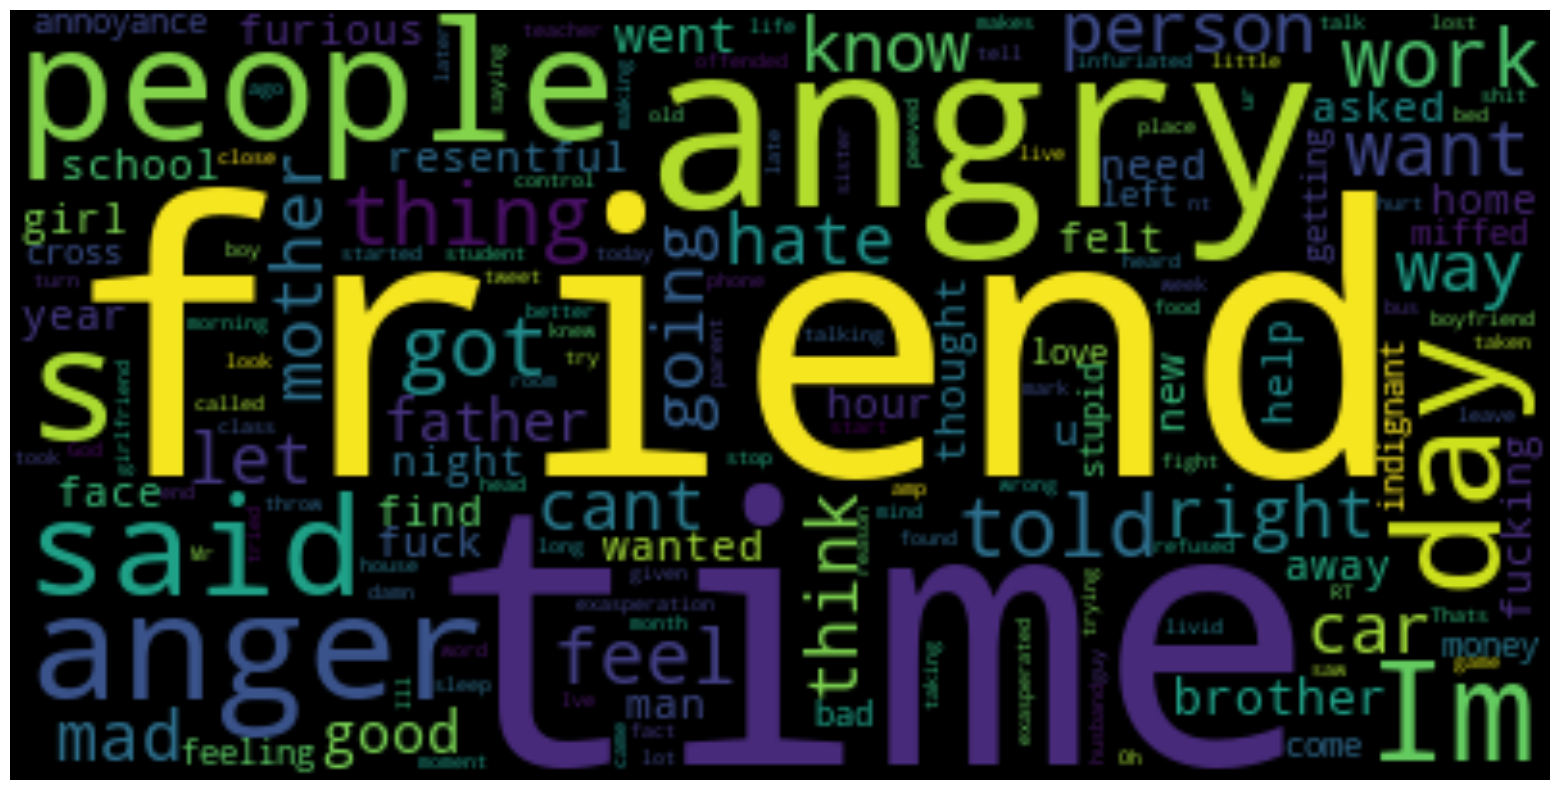

In [48]:
plot_cloud(anger_docx)

In [50]:
# Model Prediction - Machine Learning
# Importing necessary machine learning libraries
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.model_selection import train_test_split

In [51]:
# Mapping the features to a variable
x_label=df['Clean_text']
y_label=df['Emotion']

In [52]:
x_label

0                                                         
1                           Sage Act upgrade list tommorow
2        WAY HOMEGIRL BABY FUNERAL MAN HATE FUNERALS SH...
3        eye  true hazel eyeand brilliant  Regular feat...
4          ugh babe hugggzzz u  babe naamazed nga ako e...
                               ...                        
34787           gift Hope like it hand wear  Itll warm Lol
34788           world didnt meso world DEFINITELY cnt away
34789                                    man robbed today 
34790                            Youu JEALOUSY #Losing YOU
34791                                think baby dream time
Name: Clean_text, Length: 34792, dtype: object

In [53]:
y_label

0         neutral
1             joy
2         sadness
3             joy
4             joy
           ...   
34787    surprise
34788         joy
34789       anger
34790        fear
34791     sadness
Name: Emotion, Length: 34792, dtype: object

In [54]:
# Model Fitting
cv=CountVectorizer()
x=cv.fit_transform(x_label)

In [55]:
cv.get_feature_names_out()

array(['00', '000', '000ème', ..., 'ღƪ', 'ℕoíʀ', 'ㄒʜℰℳℰ'], dtype=object)

In [56]:
x_train,x_test,y_train,y_test=train_test_split(x,y_label,test_size=0.2)

In [57]:
# Logistic Regression is used for training the model and predicting the message
model=LogisticRegression()
model.fit(x_train,y_train)

C:\Users\asus\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [58]:
model.score(x_test,y_test)

0.637160511567754

In [59]:
y_pred=model.predict(x_test)
y_pred

array(['anger', 'joy', 'sadness', ..., 'neutral', 'joy', 'joy'],
      dtype=object)

In [60]:
# A sample text is given to test the model for emotion prediction
sample=["get lost idiot"]

In [61]:
vt=cv.transform(sample).toarray()
model.predict(vt)

array(['anger'], dtype=object)

In [63]:
# Probabilty of the emotion occurence is calculated
#probability check
model.predict_proba(vt)

array([[0.21090317, 0.04537643, 0.08966818, 0.16562205, 0.16136066,
        0.18980305, 0.0028701 , 0.13439636]])

In [64]:
# Emotion classes
model.classes_

array(['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'shame',
       'surprise'], dtype=object)

In [65]:
def pred_emotion(sample,model):
    vect=cv.transform(sample).toarray()
    pred=model.predict(vect)
    pred_proba=model.predict_proba(vect)
    pred_percetage=dict(zip(model.classes_,pred_proba[0]))
    print("Prediction : {}, Prediction Score: {}".format(pred[0],np.max(pred_proba)))
    print(pred[0])
    return pred_percetage

In [66]:
pred_emotion(sample,model)

Prediction : anger, Prediction Score: 0.21090316931134648
anger


{'anger': 0.21090316931134648,
 'disgust': 0.04537642662419636,
 'fear': 0.08966818195857532,
 'joy': 0.16562205489885523,
 'neutral': 0.16136065916845316,
 'sadness': 0.18980305242993847,
 'shame': 0.0028700970761356224,
 'surprise': 0.13439635853249932}

In [67]:
pred_emotion(["I love running"],model)

Prediction : joy, Prediction Score: 0.4686113846630133
joy


{'anger': 0.07175923422031628,
 'disgust': 0.009158647684687254,
 'fear': 0.16795939392656545,
 'joy': 0.4686113846630133,
 'neutral': 0.08935462467769581,
 'sadness': 0.07309166102406765,
 'shame': 0.0013571721064006609,
 'surprise': 0.1187078816972536}

In [68]:
# Model Evaluation
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       anger       0.62      0.53      0.57       832
     disgust       0.63      0.22      0.32       175
        fear       0.76      0.66      0.70      1104
         joy       0.63      0.77      0.69      2196
     neutral       0.62      0.74      0.67       483
     sadness       0.60      0.61      0.60      1337
       shame       1.00      0.80      0.89        25
    surprise       0.58      0.44      0.50       807

    accuracy                           0.64      6959
   macro avg       0.68      0.59      0.62      6959
weighted avg       0.64      0.64      0.63      6959



In [69]:
# Constructing a confusion matrix for the model
confusion_matrix(y_test,y_pred)

array([[ 440,    4,   44,  148,   51,  121,    0,   24],
       [  29,   38,   12,   50,    5,   31,    0,   10],
       [  50,    6,  727,  145,   37,   99,    0,   40],
       [  74,    3,   59, 1688,   79,  168,    0,  125],
       [  12,    1,   10,   66,  357,   32,    0,    5],
       [  72,    4,   64,  305,   27,  810,    0,   55],
       [   1,    0,    0,    1,    0,    3,   20,    0],
       [  30,    4,   45,  268,   20,   86,    0,  354]], dtype=int64)